In [2]:
# Install necessary libraries if not already present in Colab
!pip install statsmodels filterpy

# Standard library imports
import json
import os

# Third-party library imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt

# Time series specific imports
from statsmodels.tsa.seasonal import seasonal_decompose
from filterpy.kalman import KalmanFilter # filterpy库中的KalmanFilter

# Sympy (as in your original file, though its direct use isn't apparent in the main flow)
import sympy

print("--- Library Imports Complete ---")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 16.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=620de8d57166fff6f2ee17e6e02bb90cfbdf7e05c3f9650e1989261c6473ac56
  Stored in directory: /root/.cache/pip/wheels/12/dc/3c/e12983eac132d00f82a20c6cbe7b42ce6e96190ef8fa2d15e1
Successfully built filterpy
--- Library Imports Complete ---


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Setup device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Environment Setup ---")
print(f"Using device: {device}")
print(f"PyTorch Version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"CUDA available. GPU: {torch.cuda.get_device_name(0)}")
    print(f"PyTorch built with CUDA version: {torch.version.cuda}")
else:
    print("CUDA not available. Running on CPU.")
print(f"Sympy Version: {sympy.__version__}") # From your original script
print(f"--- Setup Complete ---")

# --- File Paths (Colab specific) ---
DATA_FILE_COLAB_PATH = '/content/drive/MyDrive/data/realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv'
LABEL_FILE_COLAB_PATH = '/content/drive/MyDrive/labels/combined_windows.json'
JSON_KEY_FOR_LABELS = 'realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv' # Key in the JSON label file

# --- Constants for Ablation Study ---
class PreprocessingMode:
    RAW = "RAW"
    RTS_ONLY = "RTS_ONLY"
    SD_ONLY = "SD_ONLY"
    KF_ONLY = "KF_ONLY"
    RTS_SD = "RTS_SD"
    RTS_KF = "RTS_KF"
    SD_KF = "SD_KF"
    RTS_SD_KF = "RTS_SD_KF" # Original full pipeline

# --- General Parameters ---
DECOMPOSITION_PERIOD = 60 # Period for seasonal decomposition (RTS/SD)
KF_PROCESSING_FREQ = "5min" # Resampling frequency for Kalman Filter

# LSTM Model and Training Hyperparameters (can be tuned)
LSTM_SEQUENCE_LENGTH = 30
LSTM_BATCH_SIZE = 32
LSTM_NUM_EPOCHS = 30 # Adjust as needed for convergence
LSTM_LEARNING_RATE = 0.001
LSTM_INPUT_DIM = 1  # Univariate time series
LSTM_HIDDEN_DIM = 64
LSTM_NUM_LAYERS = 2

# Kalman Filter Parameters (can be tuned)
KF_Q_NOISE = 1e-3   # Process noise
KF_R_NOISE = 0.04   # Measurement noise
KF_INIT_VAR = 1.0   # Initial state covariance

print("--- Constants and Paths Defined ---")

--- Environment Setup ---
Using device: cuda
PyTorch Version: 2.6.0+cu124
CUDA available. GPU: Tesla T4
PyTorch built with CUDA version: 12.4
Sympy Version: 1.13.1
--- Setup Complete ---
--- Constants and Paths Defined ---


In [5]:
print(f"\n--- Data Loading and Initial Labeling ---")
data_df = None
try:
    data_df = pd.read_csv(DATA_FILE_COLAB_PATH)
    print(f"Successfully loaded data from: {DATA_FILE_COLAB_PATH}")
    data_df['timestamp'] = pd.to_datetime(data_df['timestamp'])
    data_df = data_df.set_index('timestamp')
    print("Timestamp column processed and set as index.")
except Exception as e:
    print(f"Error during data loading or initial timestamp processing: {e}")
    # raise # Uncomment to stop execution on error

if data_df is not None:
    data_df['is_anomaly'] = 0 # Initialize anomaly column
    parsed_anomaly_windows_count_initial = 0
    try:
        with open(LABEL_FILE_COLAB_PATH, 'r') as f:
            all_labels_json = json.load(f)

        raw_anomaly_windows_list = all_labels_json.get(JSON_KEY_FOR_LABELS, [])
        if raw_anomaly_windows_list:
            for window_event in raw_anomaly_windows_list:
                if isinstance(window_event, list) and len(window_event) == 2:
                    try:
                        start_ts = pd.to_datetime(window_event[0])
                        end_ts = pd.to_datetime(window_event[1])
                        anomalous_points_mask = (data_df.index >= start_ts) & (data_df.index <= end_ts)
                        data_df.loc[anomalous_points_mask, 'is_anomaly'] = 1
                        if anomalous_points_mask.sum() > 0:
                            parsed_anomaly_windows_count_initial += 1
                    except Exception as e_win:
                        print(f"  Warning: Could not process window event {window_event} for initial labeling: {e_win}")
            print(f"Initial label processing complete. Processed {parsed_anomaly_windows_count_initial} anomaly window(s).")
            print(f"Total data points initially marked as anomalous in data_df: {data_df['is_anomaly'].sum()}")
        else:
            print(f"No anomaly windows found for key '{JSON_KEY_FOR_LABELS}' for initial labeling.")
    except Exception as e_label:
        print(f"An error occurred during initial label processing: {e_label}")
else:
    print("data_df is None. Skipping initial labeling.")

print(f"--- Data Loading and Initial Labeling Complete ---")


--- Data Loading and Initial Labeling ---
Successfully loaded data from: /content/drive/MyDrive/data/realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv
Timestamp column processed and set as index.
Initial label processing complete. Processed 2 anomaly window(s).
Total data points initially marked as anomalous in data_df: 402
--- Data Loading and Initial Labeling Complete ---


In [6]:
print(f"\n--- Preprocessing Function Definitions ---")

# --- 1. Seasonal Decomposition Function (for RTS and SD if SD is also decomp) ---
def apply_seasonal_decomposition(data_series: pd.Series, period: int = DECOMPOSITION_PERIOD, visualize=False) -> pd.Series:
    """Applies seasonal decomposition and returns the residual component."""
    print(f"Applying seasonal decomposition with period = {period}...")
    if not isinstance(data_series, pd.Series):
        print("Error: Input to seasonal decomposition must be a pandas Series.")
        return pd.Series(dtype=float) # Return empty series on error

    if len(data_series) > 2 * period and not data_series.isnull().all():
        try:
            # Ensure no NaNs are passed if model='additive' and there are leading/trailing NaNs in data.
            # However, seasonal_decompose handles internal NaNs by propagating them.
            # For very sparse series, decomposition might fail or produce mostly NaNs.
            series_to_decompose = data_series.fillna(method='ffill').fillna(method='bfill') # Pre-fill for robustness
            if series_to_decompose.isnull().all(): # Check again after fill
                 print("Series is all NaNs after attempting fill. Cannot decompose.")
                 return data_series.copy() # Return original if it can't be helped


            decomposition = seasonal_decompose(series_to_decompose, model='additive', period=period)
            print("Seasonal decomposition complete.")

            if visualize:
                fig_decomp, axes_decomp = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
                decomposition.observed.plot(ax=axes_decomp[0], legend=False, title='Observed')
                axes_decomp[0].set_ylabel('Observed')
                decomposition.trend.plot(ax=axes_decomp[1], legend=False, title='Trend')
                axes_decomp[1].set_ylabel('Trend')
                decomposition.seasonal.plot(ax=axes_decomp[2], legend=False, title='Seasonal')
                axes_decomp[2].set_ylabel('Seasonal')
                decomposition.resid.plot(ax=axes_decomp[3], legend=False, title='Residual')
                axes_decomp[3].set_ylabel('Residual')
                plt.tight_layout()
                plt.show()

            # Return residual, keeping the original index as much as possible
            # seasonal_decompose aligns output index with input.
            return decomposition.resid
        except Exception as e:
            print(f"Error during seasonal decomposition: {e}. Returning original series.")
            return data_series.copy()
    else:
        print(f"Not enough data (len: {len(data_series)}) or all NaNs for seasonal decomposition with period {period}. Returning original series copy.")
        return data_series.copy()

# --- 2. SD Processing Function (User-defined or defaults to seasonal decomposition) ---
def apply_sd_processing(data_series: pd.Series, period: int = DECOMPOSITION_PERIOD, visualize=False) -> pd.Series:
    """
    Applies 'SD' processing.
    CURRENTLY: Assumed to be the same as RTS (seasonal decomposition).
    MODIFY THIS FUNCTION if 'SD' means a different type of processing.
    """
    print("Applying SD processing (currently configured as seasonal decomposition)...")
    # If SD is a different method (e.g., specific denoising, smoothing), implement it here.
    # For now, it mirrors RTS:
    return apply_seasonal_decomposition(data_series, period=period, visualize=visualize)


# --- 3. Kalman Filter + RTS Smoother Function (from your original script) ---
def kf_rts_fill_revised(
        ts_values_input: np.ndarray,
        ts_index_input: pd.DatetimeIndex,
        freq: str = KF_PROCESSING_FREQ,
        Q_kf: float = KF_Q_NOISE,
        R_kf: float = KF_R_NOISE,
        init_var_kf: float = KF_INIT_VAR
) -> pd.DataFrame:
    """
    KF + RTS smoothing with automatic resampling, gap-filling and denoising.
    Input `ts_values_input` can have NaNs. The function resamples to `freq`.
    """
    print(f"Applying Kalman Filter + RTS Smoother (freq: {freq}, Q: {Q_kf}, R: {R_kf})...")
    if ts_values_input is None or ts_index_input is None:
        print("Error: Input values or timestamps for KF are None.")
        return pd.DataFrame()

    df_original_input = pd.DataFrame({'value_raw': ts_values_input}, index=ts_index_input)
    df_resampled = df_original_input.resample(freq).mean() # Resample and average

    z_observations = df_resampled['value_raw'].to_numpy(dtype=float)
    mask_observed = ~np.isnan(z_observations)

    if not mask_observed.any():
        print("Warning: After resampling, no valid observations found for KF. Returning empty DataFrame.")
        return pd.DataFrame(index=df_resampled.index)

    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.F = np.array([[1., 1.], [0., 1.]]) # State transition matrix (dt=1 in resampled grid)
    kf.H = np.array([[1., 0.]])          # Observation matrix
    kf.Q = np.eye(2) * Q_kf              # Process noise covariance
    kf.R = np.array([[R_kf]])            # Observation noise covariance

    first_valid_obs_indices = np.where(mask_observed)[0]
    initial_value = z_observations[first_valid_obs_indices[0]] if len(first_valid_obs_indices) > 0 else 0.0

    kf.x = np.array([[initial_value], [0.]]) # Initial state [value, velocity]
    kf.P = np.eye(2) * init_var_kf        # Initial state covariance

    num_resampled_steps = len(z_observations)
    filtered_means = np.zeros((num_resampled_steps, kf.dim_x))
    filtered_covs = np.zeros((num_resampled_steps, kf.dim_x, kf.dim_x))

    for k_step in range(num_resampled_steps):
        kf.predict()
        if mask_observed[k_step]:
            kf.update(np.array([[z_observations[k_step]]]))
        filtered_means[k_step, :] = kf.x.T
        filtered_covs[k_step, :, :] = kf.P

    # Use positional arguments for rts_smoother for broader filterpy compatibility
    smoothed_states_xs, _, _, _ = kf.rts_smoother(filtered_means, filtered_covs)

    result_df = pd.DataFrame({
        'value_smoothed': smoothed_states_xs[:, 0] # Position component
    }, index=df_resampled.index)

    print("Kalman filtering and RTS smoothing complete.")
    return result_df

# --- 4. Label Alignment Function ---
def align_labels(original_data_df_with_labels: pd.DataFrame, target_index: pd.DatetimeIndex, label_column: str ='is_anomaly') -> np.ndarray:
    """Aligns labels from original_data_df to the target_index."""
    # print(f"Aligning labels to target index of length {len(target_index)}...")
    if label_column not in original_data_df_with_labels.columns:
        print(f"Warning: Label column '{label_column}' not found in original DataFrame. Returning all zeros for labels.")
        return np.zeros(len(target_index), dtype=int)
    if target_index.empty:
        print("Warning: Target index for label alignment is empty. Returning empty array for labels.")
        return np.array([], dtype=int)

    original_labels_series = pd.Series(original_data_df_with_labels[label_column].values,
                                       index=original_data_df_with_labels.index)

    # Reindex and fill: use nearest for sparse labels, then fill any remaining NaNs (e.g., from edges) with 0
    aligned_labels = original_labels_series.reindex(target_index, method='nearest')
    aligned_labels_filled = aligned_labels.fillna(0).astype(int)

    # print(f"Labels aligned. Sum of anomalies in aligned labels: {aligned_labels_filled.sum()}")
    return aligned_labels_filled.to_numpy()

print("--- Preprocessing Function Definitions Complete ---")


--- Preprocessing Function Definitions ---
--- Preprocessing Function Definitions Complete ---


In [7]:
print(f"\n--- Downstream Model and Evaluation Function Definition ---")

# --- Helper: Create sequences for LSTM ---
def create_sequences_colab(input_data: np.ndarray, sequence_length: int) -> np.ndarray:
    sequences = []
    if len(input_data) < sequence_length:
        return np.array(sequences) # Return empty if not enough data
    for i in range(len(input_data) - sequence_length + 1):
        seq = input_data[i:(i + sequence_length)]
        sequences.append(seq)
    return np.array(sequences)

# --- LSTM Autoencoder Model Class ---
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_layers: int):
        super(LSTMAutoencoder, self).__init__()
        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        # Decoder's input_size is hidden_dim as it takes encoder's output sequence or last hidden state
        self.decoder_lstm = nn.LSTM(
            input_size=hidden_dim, # If using encoder_outputs as input to decoder LSTM layer by layer
            hidden_size=hidden_dim, # Can be different, e.g., input_dim if trying to reconstruct directly
            num_layers=num_layers,
            batch_first=True
        )
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: (batch_size, seq_len, input_dim)
        encoder_outputs, (hidden, cell) = self.encoder_lstm(x)
        # Using encoder_outputs (sequence of hidden states from encoder) as input to decoder
        decoder_outputs, _ = self.decoder_lstm(encoder_outputs, (hidden, cell))
        reconstructed_x = self.output_layer(decoder_outputs)
        return reconstructed_x

# --- Main Evaluation Function ---
def run_lstm_and_evaluate(
    time_series_processed: np.ndarray,           # Preprocessed numerical series (n_samples, 1)
    true_labels_aligned: np.ndarray,             # Labels aligned with time_series_processed
    experiment_name_for_plot: str,               # For plot titles
    original_timestamps_for_processed_series: pd.DatetimeIndex, # Timestamps for processed series
    original_data_df_for_plot: pd.DataFrame,     # Original raw data for plotting context
    kf_smoothed_df_for_plot: pd.DataFrame = None,# KF output if used, for plotting
    sequence_length: int = LSTM_SEQUENCE_LENGTH,
    batch_size: int = LSTM_BATCH_SIZE,
    num_epochs: int = LSTM_NUM_EPOCHS,
    learning_rate: float = LSTM_LEARNING_RATE,
    input_dim: int = LSTM_INPUT_DIM,
    hidden_dim: int = LSTM_HIDDEN_DIM,
    num_layers: int = LSTM_NUM_LAYERS,
    visualize_training_loss: bool = False,
    visualize_final_results: bool = False
) -> dict:
    """
    Runs the LSTM autoencoder training, anomaly scoring, and evaluation.
    Returns a dictionary of performance metrics.
    """
    print(f"\n--- LSTM Pipeline for: {experiment_name_for_plot} ---")
    results = {"precision": 0.0, "recall": 0.0, "f1": 0.0, "cm": np.zeros((2,2), dtype=int), "status": "Not Run"}

    if time_series_processed is None or true_labels_aligned is None or len(time_series_processed) == 0:
        print("Skipping LSTM: Missing processed data or labels.")
        results["status"] = "Skipped - Missing data/labels"
        return results
    if len(time_series_processed) != len(true_labels_aligned):
        print(f"CRITICAL ERROR: Length mismatch! Data: {len(time_series_processed)}, Labels: {len(true_labels_aligned)}")
        results["status"] = "Error - Data/Label length mismatch"
        return results
    if len(time_series_processed) < sequence_length:
        print(f"Skipping LSTM: Data length ({len(time_series_processed)}) is less than sequence length ({sequence_length}).")
        results["status"] = "Skipped - Insufficient data for sequences"
        return results

    # 1. LSTM Data Preprocessing
    print("Starting LSTM data preprocessing...")
    scaler = MinMaxScaler(feature_range=(-1, 1))
    time_series_scaled = scaler.fit_transform(time_series_processed) # Expects (n_samples, n_features)

    X_sequences = create_sequences_colab(time_series_scaled, sequence_length)
    if X_sequences.shape[0] == 0:
        print("Skipping LSTM: No sequences created (check data length and sequence length).")
        results["status"] = "Skipped - No sequences formed"
        return results

    X_tensor = torch.tensor(X_sequences, dtype=torch.float32).to(device)
    # For autoencoder, target is the same as input
    y_tensor = torch.tensor(X_sequences, dtype=torch.float32).to(device)
    print(f"Data scaled & sequences created. X_tensor shape: {X_tensor.shape}")

    dataset = TensorDataset(X_tensor, y_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True) # drop_last if batch_size doesn't divide dataset size
    print(f"DataLoader created with batch size {batch_size}.")

    # 2. Model Definition
    model = LSTMAutoencoder(input_dim, hidden_dim, num_layers).to(device)
    # print(model)

    # 3. Model Training
    print("Starting model training...")
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_history = {'train_loss': []}

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        for seq_in, seq_target in dataloader:
            optimizer.zero_grad()
            seq_pred = model(seq_in)
            loss = criterion(seq_pred, seq_target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(dataloader) if len(dataloader) > 0 else float('inf')
        train_history['train_loss'].append(avg_epoch_loss)
        if (epoch + 1) % 5 == 0 or epoch == num_epochs - 1:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.6f}")
    print("Training finished.")

    if visualize_training_loss:
        plt.figure(figsize=(10, 4))
        plt.plot(train_history['train_loss'], label='Training Loss')
        plt.title(f'Training Loss Over Epochs - {experiment_name_for_plot}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

    # 4. Anomaly Score Calculation
    print("Calculating anomaly scores...")
    model.eval()
    reconstruction_errors_per_sequence = []
    with torch.no_grad():
        # Iterate through X_tensor to get predictions for all sequences
        # Can do this batch-wise or sequence by sequence if memory is an issue for large X_tensor
        # For simplicity, using a temporary dataloader without shuffle for full X_tensor
        eval_dataset = TensorDataset(X_tensor, X_tensor) # Input and target are the same
        eval_dataloader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

        for seq_batch_in, seq_batch_target in eval_dataloader:
            seq_batch_pred = model(seq_batch_in)
            # Calculate MSE loss for each sequence in the batch
            errors_batch = torch.mean((seq_batch_pred - seq_batch_target)**2, dim=[1,2]) # Mean over seq_len and features
            reconstruction_errors_per_sequence.extend(errors_batch.cpu().tolist())

    reconstruction_errors_per_sequence = np.array(reconstruction_errors_per_sequence)

    # Map sequence errors back to individual time points
    # The error of a sequence is typically assigned to its last point or center point.
    # Your original code assigns to the last point.
    anomaly_scores = np.full(len(time_series_scaled), np.nan)
    if len(reconstruction_errors_per_sequence) == X_sequences.shape[0]: # Should match
        for i in range(len(reconstruction_errors_per_sequence)):
            anomaly_scores[i + sequence_length - 1] = reconstruction_errors_per_sequence[i]
    else: # Should not happen if create_sequences and error calculation are correct
        print(f"Warning: Mismatch in number of sequences ({X_sequences.shape[0]}) and errors ({len(reconstruction_errors_per_sequence)}). Scores might be incorrect.")
        # Fallback: Pad anomaly_scores if error array is shorter
        valid_len = min(len(reconstruction_errors_per_sequence), len(anomaly_scores) - sequence_length + 1)
        for i in range(valid_len):
            anomaly_scores[i + sequence_length - 1] = reconstruction_errors_per_sequence[i]


    # Fill NaNs at the beginning of anomaly_scores (due to sequence window)
    first_valid_score_idx = np.where(~np.isnan(anomaly_scores))[0]
    if len(first_valid_score_idx) > 0:
        anomaly_scores[:first_valid_score_idx[0]] = anomaly_scores[first_valid_score_idx[0]] # Pad with first valid score
    elif len(anomaly_scores) > 0 : # All NaNs, means no valid scores (e.g. if not enough data)
        anomaly_scores[:] = 0 # Default to 0 if no scores could be computed

    # 5. Thresholding and Evaluation
    print("Thresholding and evaluating...")
    # Use true_labels_aligned which corresponds to the points in time_series_scaled/anomaly_scores
    eval_true_labels = true_labels_aligned

    # Ensure no NaNs in scores used for thresholding if any remain (shouldn't if padded)
    valid_score_indices = ~np.isnan(anomaly_scores)
    if not np.any(valid_score_indices):
        print("No valid anomaly scores for evaluation.")
        results["status"] = "Evaluation Failed - No valid anomaly scores"
        return results

    threshold_scores = anomaly_scores[valid_score_indices]
    threshold_labels = eval_true_labels[valid_score_indices] # align labels to where scores are valid

    if len(threshold_scores) == 0:
        print("Not enough valid scores for thresholding/evaluation.")
        results["status"] = "Evaluation Failed - No scores for threshold"
        return results

    # Dynamic thresholding (e.g., 95th percentile of reconstruction errors)
    threshold = np.quantile(threshold_scores, 0.95)
    print(f"Anomaly threshold (95th percentile of scores): {threshold:.6f}")

    predicted_anomalies_bool = anomaly_scores > threshold # Apply threshold to all scores
    predicted_anomalies_int = predicted_anomalies_bool.astype(int)

    # Evaluate only on points where we have scores and corresponding labels
    precision, recall, f1, _ = precision_recall_fscore_support(
        eval_true_labels, # Use all original aligned labels
        predicted_anomalies_int, # Predictions for all points
        average='binary',
        zero_division=0
    )
    cm = confusion_matrix(eval_true_labels, predicted_anomalies_int)

    results = {"precision": precision, "recall": recall, "f1": f1, "cm": cm, "status": "Completed"}
    print(f"Evaluation Results for {experiment_name_for_plot}:")
    print(f"  Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")
    print(f"  Confusion Matrix:\n{cm}")

    # 6. Final Visualization (Optional)
    if visualize_final_results and original_data_df_for_plot is not None:
        plt.figure(figsize=(18, 7))

        # Plot original raw data
        plt.plot(original_data_df_for_plot.index, original_data_df_for_plot['value'],
                 label='Original Raw Value', color='gray', alpha=0.4, linestyle=':')

        # Plot the series that was input to the LSTM (after all preprocessing)
        # This series has timestamps: original_timestamps_for_processed_series
        # And values: time_series_processed (before scaling for LSTM)
        plt.plot(original_timestamps_for_processed_series, time_series_processed,
                 label='Input to LSTM (Processed)', color='blue', linewidth=1.2, alpha=0.7)

        # If KF was used, plot its smoothed output (if distinct and available)
        if kf_smoothed_df_for_plot is not None and not kf_smoothed_df_for_plot.empty:
             if 'value_smoothed' in kf_smoothed_df_for_plot.columns: #Check if the column exists
                plt.plot(kf_smoothed_df_for_plot.index, kf_smoothed_df_for_plot['value_smoothed'],
                         label='KF Smoothed Output', color='green', linewidth=1, alpha=0.6, linestyle='--')


        # Mark true anomalies (from original data, on the original value scale)
        true_anomalies_on_original = original_data_df_for_plot[original_data_df_for_plot['is_anomaly'] == 1]
        if not true_anomalies_on_original.empty:
            plt.scatter(true_anomalies_on_original.index, true_anomalies_on_original['value'],
                        color='red', label='True Anomaly (Original Data)', marker='o', s=60, alpha=0.7, zorder=3)

        # Mark detected anomalies. These are on the 'time_series_processed' timeline.
        # We need to get the values from 'time_series_processed' at these detected points.
        detected_anomaly_indices = np.where(predicted_anomalies_int == 1)[0]
        if len(detected_anomaly_indices) > 0:
            detected_timestamps = original_timestamps_for_processed_series[detected_anomaly_indices]
            detected_values_on_processed_series = time_series_processed[detected_anomaly_indices].flatten()

            plt.scatter(detected_timestamps, detected_values_on_processed_series,
                        color='purple', label='Detected Anomaly (on Processed Series)',
                        marker='x', s=80, alpha=0.9, zorder=4)

        plt.title(f"Anomaly Detection: {experiment_name_for_plot}")
        plt.xlabel("Timestamp")
        plt.ylabel("Value")
        plt.legend(loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    return results

print("--- Downstream Model and Evaluation Function Definition Complete ---")


--- Downstream Model and Evaluation Function Definition ---
--- Downstream Model and Evaluation Function Definition Complete ---


In [8]:
print(f"\n--- Ablation Study Configuration ---")

# Ensure data_df is loaded from Cell 3
if 'data_df' not in locals() or data_df is None:
    print("ERROR: data_df not loaded. Please run Cell 3 first.")
    # raise RuntimeError("data_df not loaded.") # Or handle more gracefully

# Define the experiment configurations for the ablation study
# Each key is a name for the experiment (e.g., P_RTS),
# and value is a dict with 'steps' (list of preprocessing functions to apply in order)
# and 'desc' (a description).
experiment_configurations = {
    "P_RAW":    {"steps": [], "desc": "原始数据 -> 模型 (无显式预处理)"}, # Baseline
    "P_RTS":    {"steps": ["RTS"], "desc": "原始数据 -> RTS -> 模型"},
    "P_SD":     {"steps": ["SD"],  "desc": "原始数据 -> SD -> 模型"}, # Assumes SD is defined
    "P_KF":     {"steps": ["KF"],  "desc": "原始数据 -> KF -> 模型"},
    "P_RTS_SD": {"steps": ["RTS", "SD"], "desc": "原始数据 -> RTS -> SD -> 模型"}, # SD applied to RTS output
    "P_RTS_KF": {"steps": ["RTS", "KF"], "desc": "原始数据 -> RTS -> KF -> 模型"}, # KF applied to RTS output
    "P_SD_KF":  {"steps": ["SD", "KF"],  "desc": "原始数据 -> SD -> KF -> 模型"},  # KF applied to SD output
    # Optional: Full original pipeline if it was RTS -> (some form of SD on RTS output) -> KF
    # "P_RTS_SD_KF": {"steps": ["RTS", "SD", "KF"], "desc": "原始数据 -> RTS -> SD -> KF -> 模型"}
}
# You requested these 6 specific modes (plus RAW as a good baseline):
# 原始数据 -> RTS -> 模型 (P_RTS)
# 原始数据 -> SD -> 模型 (P_SD)
# 原始数据 -> KF -> 模型 (P_KF)
# 原始数据 -> RTS -> SD -> 模型 (P_RTS_SD)
# 原始数据 -> RTS -> KF -> 模型 (P_RTS_KF)
# 原始数据 -> SD -> KF -> 模型 (P_SD_KF)

# Select which experiments to run (can comment out to run a subset)
active_experiments = [
    "P_RAW",
    "P_RTS",
    "P_SD",
    "P_KF",
    "P_RTS_SD",
    "P_RTS_KF",
    "P_SD_KF",
]
# To run only user's specified 6:
# active_experiments = ["P_RTS", "P_SD", "P_KF", "P_RTS_SD", "P_RTS_KF", "P_SD_KF"]


all_experiment_results = {}

print("--- Ablation Study Configuration Complete ---")
print(f"Will run the following experiments: {active_experiments}")


--- Ablation Study Configuration ---
--- Ablation Study Configuration Complete ---
Will run the following experiments: ['P_RAW', 'P_RTS', 'P_SD', 'P_KF', 'P_RTS_SD', 'P_RTS_KF', 'P_SD_KF']



--- Starting Ablation Study Main Loop ---


===== Running Experiment: P_RAW (原始数据 -> 模型 (无显式预处理)) =====
Mode: RAW data. No explicit preprocessing steps.
Final preprocessed data for LSTM: Length 4032
Aligned labels for LSTM: Length 4032

--- LSTM Pipeline for: P_RAW ---
Starting LSTM data preprocessing...
Data scaled & sequences created. X_tensor shape: torch.Size([4003, 30, 1])
DataLoader created with batch size 32.
Starting model training...
Epoch [5/30], Loss: 0.029671
Epoch [10/30], Loss: 0.000071
Epoch [15/30], Loss: 0.000019
Epoch [20/30], Loss: 0.000019
Epoch [25/30], Loss: 0.000015
Epoch [30/30], Loss: 0.000022
Training finished.
Calculating anomaly scores...
Thresholding and evaluating...
Anomaly threshold (95th percentile of scores): 0.000012
Evaluation Results for P_RAW:
  Precision: 0.4653, Recall: 0.2338, F1-Score: 0.3113
  Confusion Matrix:
[[3522  108]
 [ 308   94]]


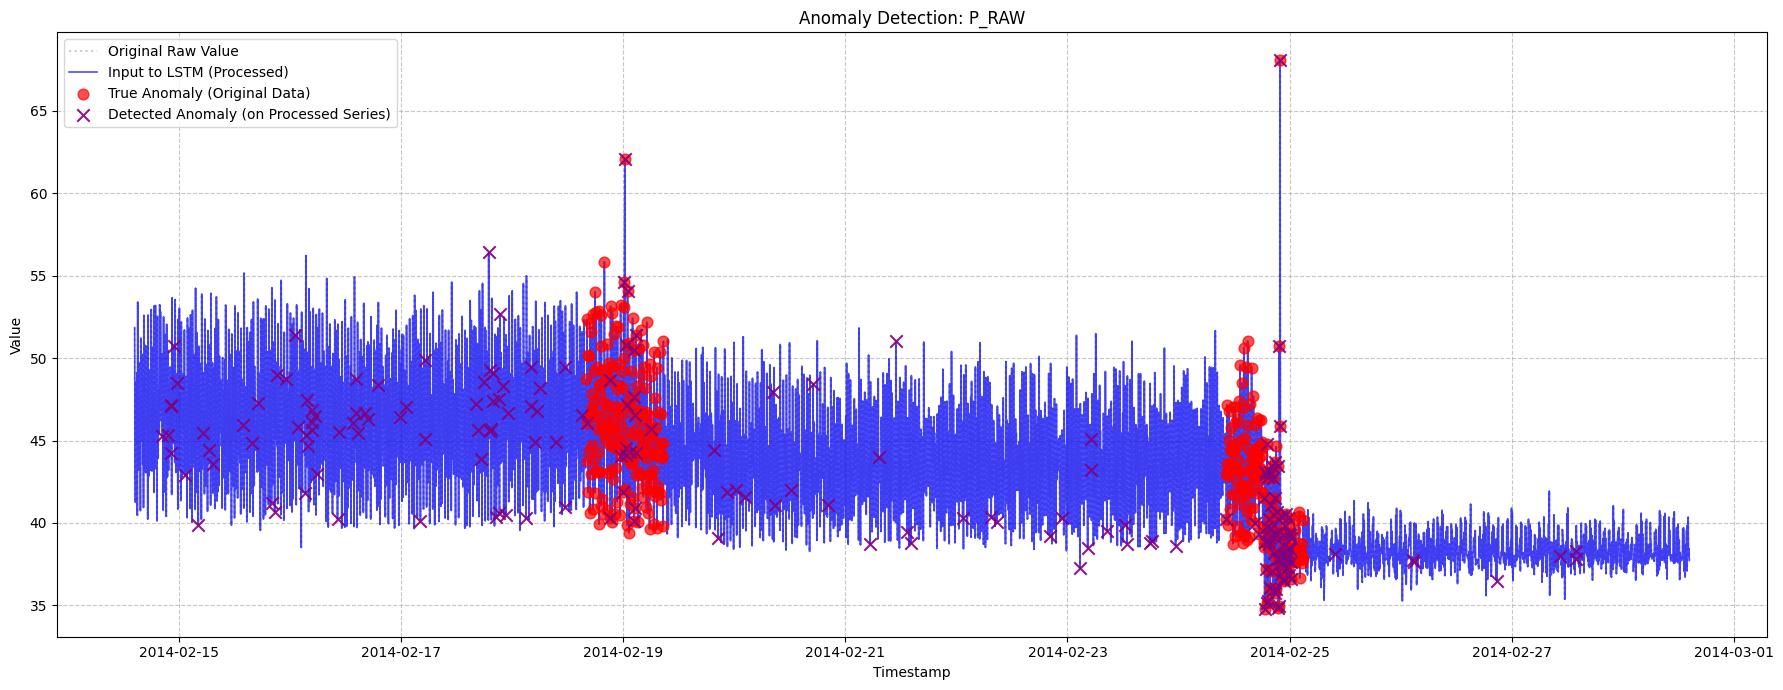



===== Running Experiment: P_RTS (原始数据 -> RTS -> 模型) =====

-- Applying Step: RTS --
Applying seasonal decomposition with period = 60...
Seasonal decomposition complete.
Series after RTS: Length 4032, NaNs 60
Series for LSTM (from RTS) has 60 NaNs. Applying ffill & bfill.
Final preprocessed data for LSTM: Length 4032
Aligned labels for LSTM: Length 4032

--- LSTM Pipeline for: P_RTS ---
Starting LSTM data preprocessing...
Data scaled & sequences created. X_tensor shape: torch.Size([4003, 30, 1])
DataLoader created with batch size 32.
Starting model training...


<ipython-input-6-6b952e30ee6f>:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_to_decompose = data_series.fillna(method='ffill').fillna(method='bfill') # Pre-fill for robustness


Epoch [5/30], Loss: 0.027451
Epoch [10/30], Loss: 0.000164
Epoch [15/30], Loss: 0.000093
Epoch [20/30], Loss: 0.000062
Epoch [25/30], Loss: 0.000023
Epoch [30/30], Loss: 0.000028
Training finished.
Calculating anomaly scores...
Thresholding and evaluating...
Anomaly threshold (95th percentile of scores): 0.000012
Evaluation Results for P_RTS:
  Precision: 0.4505, Recall: 0.2264, F1-Score: 0.3013
  Confusion Matrix:
[[3519  111]
 [ 311   91]]


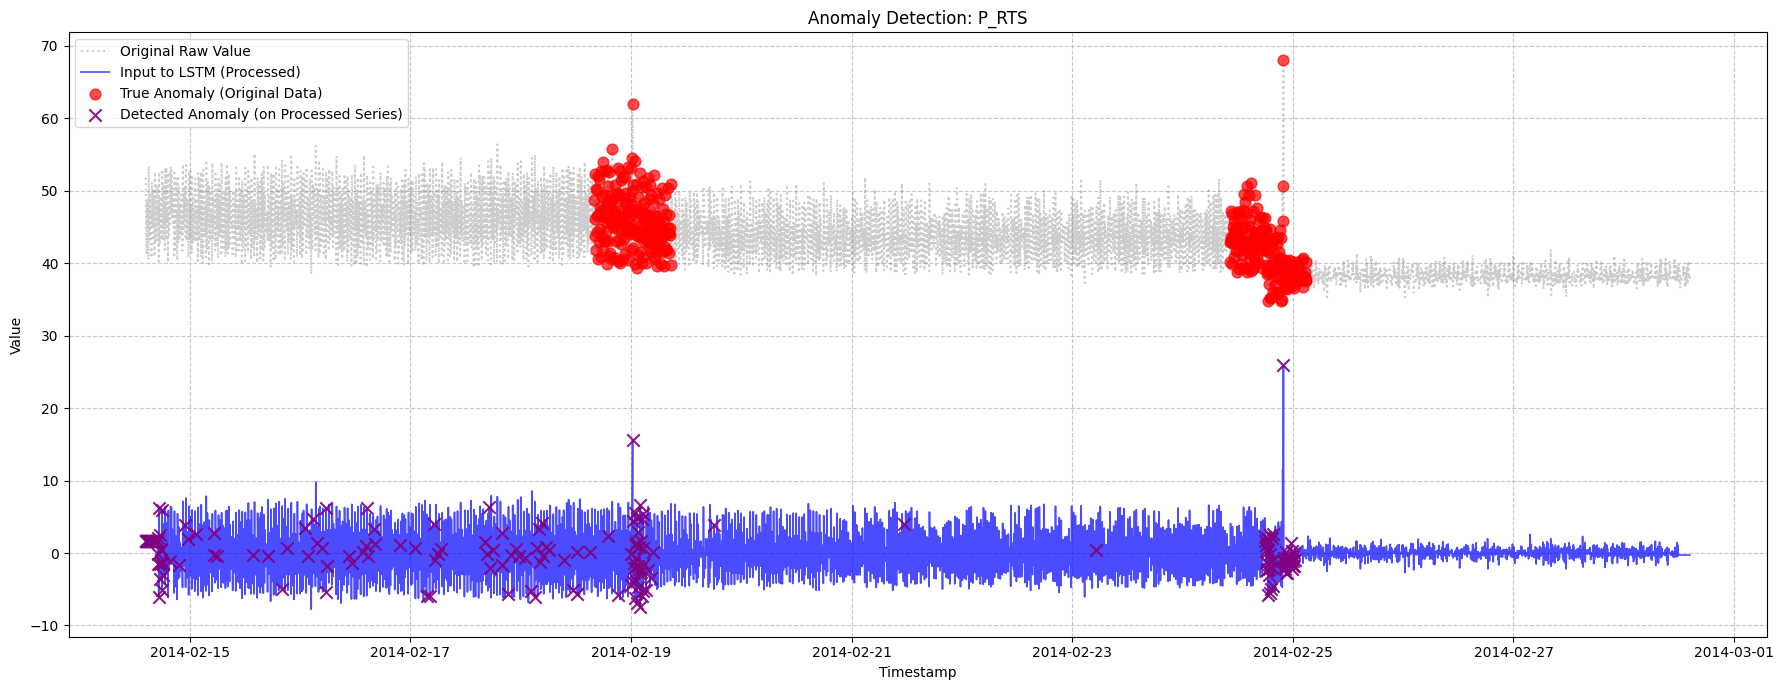



===== Running Experiment: P_SD (原始数据 -> SD -> 模型) =====

-- Applying Step: SD --
Applying SD processing (currently configured as seasonal decomposition)...
Applying seasonal decomposition with period = 60...
Seasonal decomposition complete.
Series after SD: Length 4032, NaNs 60
Series for LSTM (from SD) has 60 NaNs. Applying ffill & bfill.
Final preprocessed data for LSTM: Length 4032
Aligned labels for LSTM: Length 4032

--- LSTM Pipeline for: P_SD ---
Starting LSTM data preprocessing...
Data scaled & sequences created. X_tensor shape: torch.Size([4003, 30, 1])
DataLoader created with batch size 32.
Starting model training...


<ipython-input-6-6b952e30ee6f>:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_to_decompose = data_series.fillna(method='ffill').fillna(method='bfill') # Pre-fill for robustness


Epoch [5/30], Loss: 0.027463
Epoch [10/30], Loss: 0.000116
Epoch [15/30], Loss: 0.000050
Epoch [20/30], Loss: 0.000036
Epoch [25/30], Loss: 0.000018
Epoch [30/30], Loss: 0.000014
Training finished.
Calculating anomaly scores...
Thresholding and evaluating...
Anomaly threshold (95th percentile of scores): 0.000029
Evaluation Results for P_SD:
  Precision: 0.5594, Recall: 0.2811, F1-Score: 0.3742
  Confusion Matrix:
[[3541   89]
 [ 289  113]]


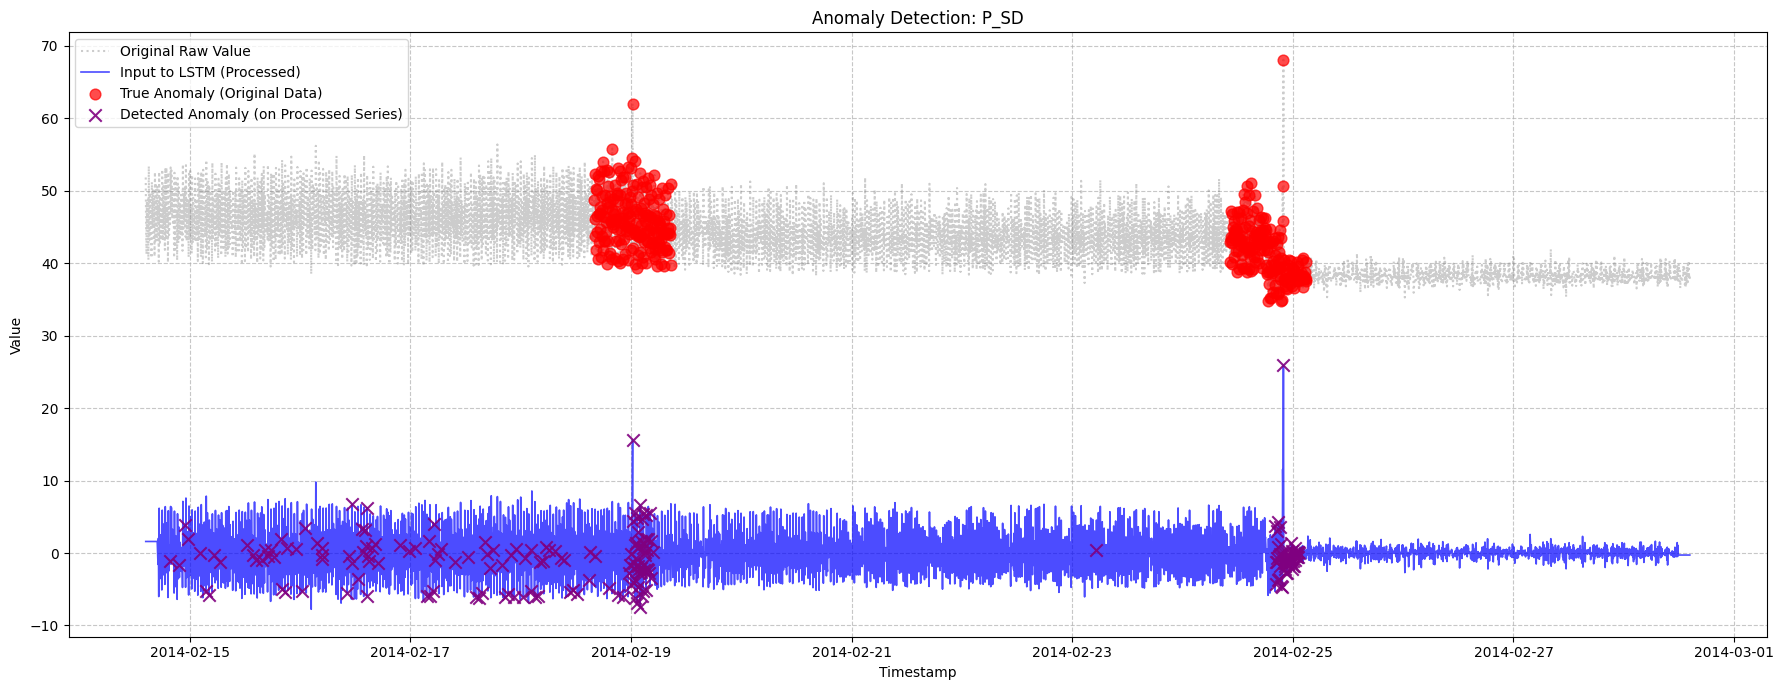



===== Running Experiment: P_KF (原始数据 -> KF -> 模型) =====

-- Applying Step: KF --
Applying Kalman Filter + RTS Smoother (freq: 5min, Q: 0.001, R: 0.04)...
Kalman filtering and RTS smoothing complete.
Series after KF: Length 4032, NaNs 0
Final preprocessed data for LSTM: Length 4032
Aligned labels for LSTM: Length 4032

--- LSTM Pipeline for: P_KF ---
Starting LSTM data preprocessing...
Data scaled & sequences created. X_tensor shape: torch.Size([4003, 30, 1])
DataLoader created with batch size 32.
Starting model training...
Epoch [5/30], Loss: 0.001735
Epoch [10/30], Loss: 0.000233
Epoch [15/30], Loss: 0.000050
Epoch [20/30], Loss: 0.000045
Epoch [25/30], Loss: 0.000013
Epoch [30/30], Loss: 0.000024
Training finished.
Calculating anomaly scores...
Thresholding and evaluating...
Anomaly threshold (95th percentile of scores): 0.000013
Evaluation Results for P_KF:
  Precision: 0.5000, Recall: 0.2512, F1-Score: 0.3344
  Confusion Matrix:
[[3529  101]
 [ 301  101]]


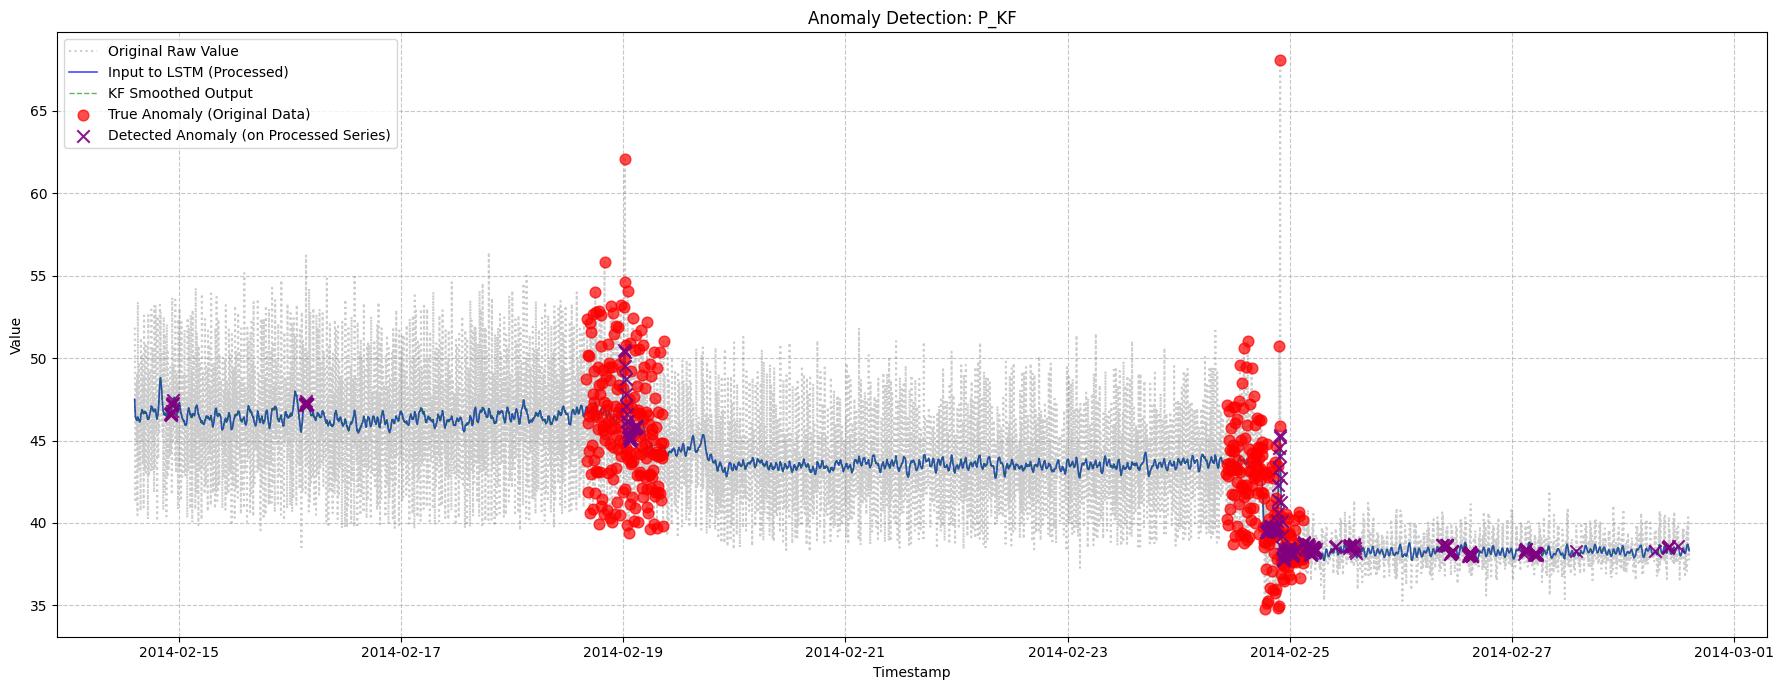



===== Running Experiment: P_RTS_SD (原始数据 -> RTS -> SD -> 模型) =====

-- Applying Step: RTS --
Applying seasonal decomposition with period = 60...
Seasonal decomposition complete.
Series after RTS: Length 4032, NaNs 60

-- Applying Step: SD --
Applying SD processing (currently configured as seasonal decomposition)...
Applying seasonal decomposition with period = 60...
Seasonal decomposition complete.
Series after SD: Length 4032, NaNs 60
Series for LSTM (from SD) has 60 NaNs. Applying ffill & bfill.
Final preprocessed data for LSTM: Length 4032
Aligned labels for LSTM: Length 4032

--- LSTM Pipeline for: P_RTS_SD ---
Starting LSTM data preprocessing...
Data scaled & sequences created. X_tensor shape: torch.Size([4003, 30, 1])
DataLoader created with batch size 32.
Starting model training...


<ipython-input-6-6b952e30ee6f>:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_to_decompose = data_series.fillna(method='ffill').fillna(method='bfill') # Pre-fill for robustness


Epoch [5/30], Loss: 0.027017
Epoch [10/30], Loss: 0.000244
Epoch [15/30], Loss: 0.000073
Epoch [20/30], Loss: 0.000019
Epoch [25/30], Loss: 0.000025
Epoch [30/30], Loss: 0.000027
Training finished.
Calculating anomaly scores...
Thresholding and evaluating...
Anomaly threshold (95th percentile of scores): 0.000021
Evaluation Results for P_RTS_SD:
  Precision: 0.4703, Recall: 0.2363, F1-Score: 0.3146
  Confusion Matrix:
[[3523  107]
 [ 307   95]]


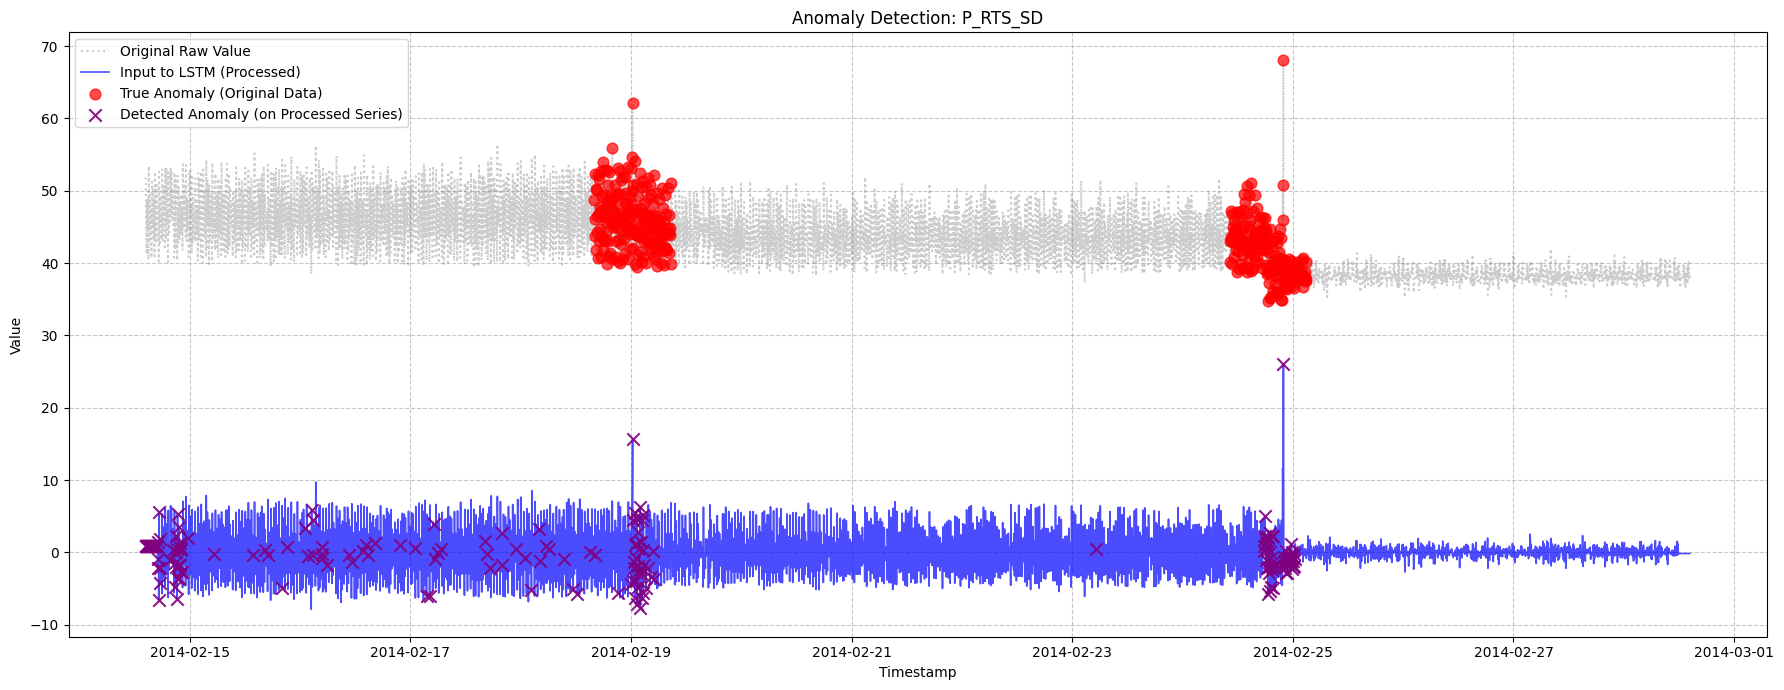



===== Running Experiment: P_RTS_KF (原始数据 -> RTS -> KF -> 模型) =====

-- Applying Step: RTS --
Applying seasonal decomposition with period = 60...
Seasonal decomposition complete.
Series after RTS: Length 4032, NaNs 60

-- Applying Step: KF --
Applying Kalman Filter + RTS Smoother (freq: 5min, Q: 0.001, R: 0.04)...


<ipython-input-6-6b952e30ee6f>:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_to_decompose = data_series.fillna(method='ffill').fillna(method='bfill') # Pre-fill for robustness


Kalman filtering and RTS smoothing complete.
Series after KF: Length 4032, NaNs 0
Final preprocessed data for LSTM: Length 4032
Aligned labels for LSTM: Length 4032

--- LSTM Pipeline for: P_RTS_KF ---
Starting LSTM data preprocessing...
Data scaled & sequences created. X_tensor shape: torch.Size([4003, 30, 1])
DataLoader created with batch size 32.
Starting model training...
Epoch [5/30], Loss: 0.000870
Epoch [10/30], Loss: 0.000114
Epoch [15/30], Loss: 0.000032
Epoch [20/30], Loss: 0.000031
Epoch [25/30], Loss: 0.000019
Epoch [30/30], Loss: 0.000030
Training finished.
Calculating anomaly scores...
Thresholding and evaluating...
Anomaly threshold (95th percentile of scores): 0.000019
Evaluation Results for P_RTS_KF:
  Precision: 0.6584, Recall: 0.3308, F1-Score: 0.4404
  Confusion Matrix:
[[3561   69]
 [ 269  133]]


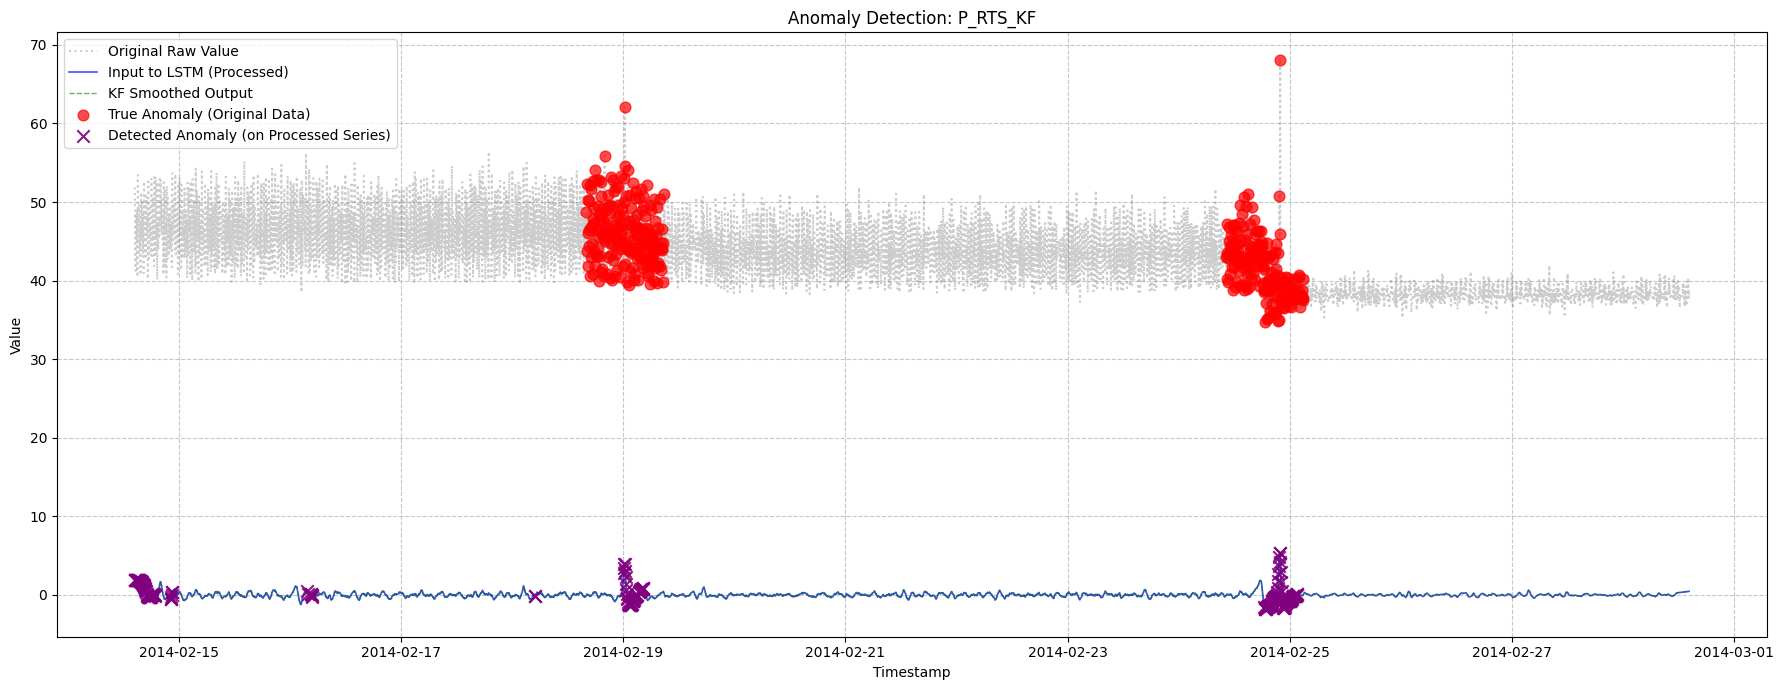



===== Running Experiment: P_SD_KF (原始数据 -> SD -> KF -> 模型) =====

-- Applying Step: SD --
Applying SD processing (currently configured as seasonal decomposition)...
Applying seasonal decomposition with period = 60...
Seasonal decomposition complete.
Series after SD: Length 4032, NaNs 60

-- Applying Step: KF --
Applying Kalman Filter + RTS Smoother (freq: 5min, Q: 0.001, R: 0.04)...


<ipython-input-6-6b952e30ee6f>:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_to_decompose = data_series.fillna(method='ffill').fillna(method='bfill') # Pre-fill for robustness


Kalman filtering and RTS smoothing complete.
Series after KF: Length 4032, NaNs 0
Final preprocessed data for LSTM: Length 4032
Aligned labels for LSTM: Length 4032

--- LSTM Pipeline for: P_SD_KF ---
Starting LSTM data preprocessing...
Data scaled & sequences created. X_tensor shape: torch.Size([4003, 30, 1])
DataLoader created with batch size 32.
Starting model training...
Epoch [5/30], Loss: 0.000675
Epoch [10/30], Loss: 0.000065
Epoch [15/30], Loss: 0.000023
Epoch [20/30], Loss: 0.000009
Epoch [25/30], Loss: 0.000015
Epoch [30/30], Loss: 0.000015
Training finished.
Calculating anomaly scores...
Thresholding and evaluating...
Anomaly threshold (95th percentile of scores): 0.000012
Evaluation Results for P_SD_KF:
  Precision: 0.7426, Recall: 0.3731, F1-Score: 0.4967
  Confusion Matrix:
[[3578   52]
 [ 252  150]]


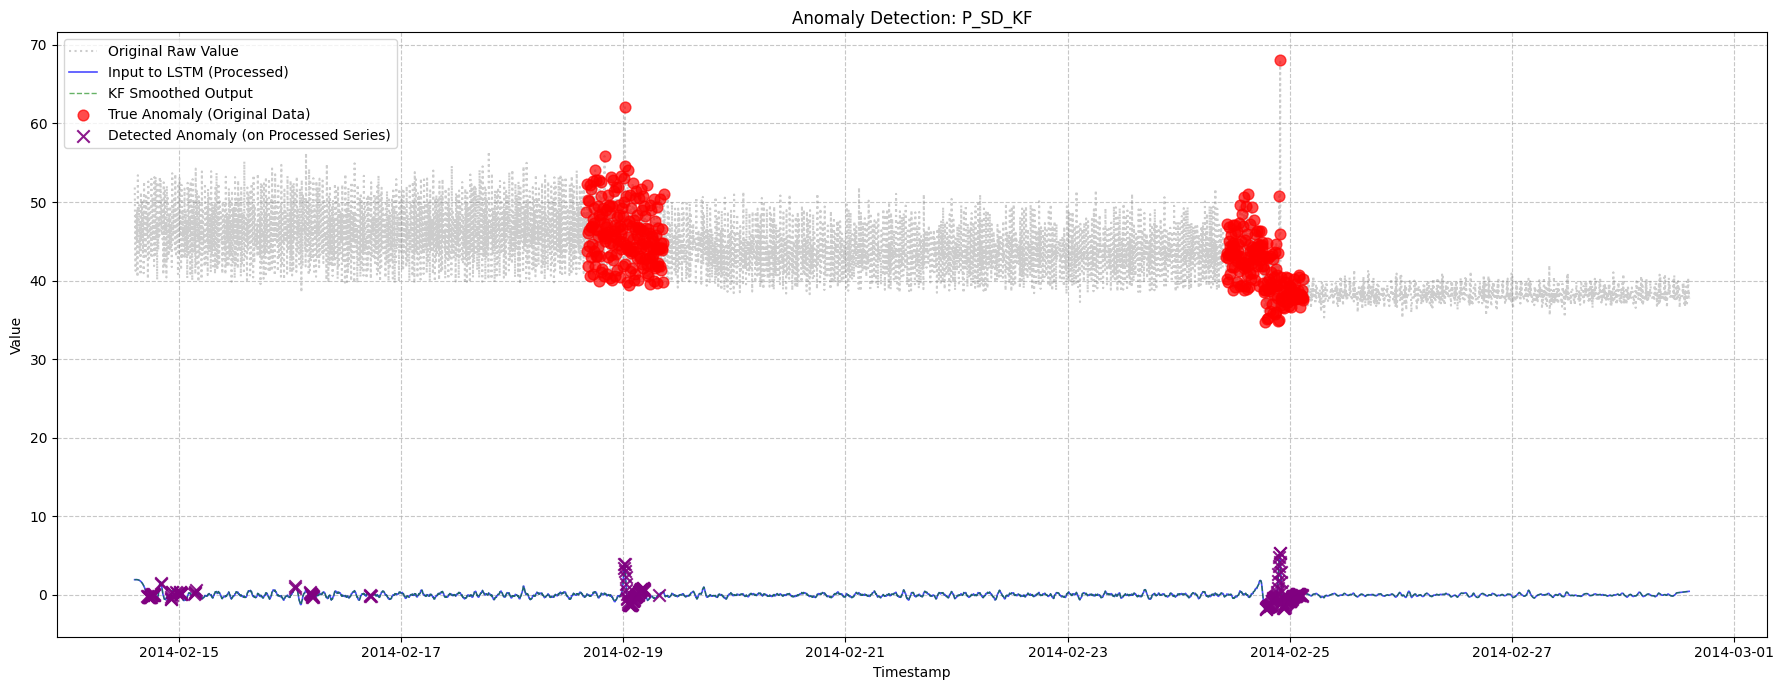


--- Ablation Study Main Loop Complete ---


In [9]:
print(f"\n--- Starting Ablation Study Main Loop ---")

if 'data_df' not in locals() or data_df is None or 'value' not in data_df.columns:
    print("Critical Error: data_df is not loaded or 'value' column is missing. Aborting study.")
else:
    for mode_name in active_experiments:
        if mode_name not in experiment_configurations:
            print(f"Warning: Configuration for mode '{mode_name}' not found. Skipping.")
            continue

        config = experiment_configurations[mode_name]
        print(f"\n\n===== Running Experiment: {mode_name} ({config['desc']}) =====")

        current_series_pd = data_df['value'].copy() # Start with raw values
        current_index_pd = data_df.index.copy()   # Corresponding index

        processed_data_for_lstm = None
        aligned_labels_for_lstm = None
        kf_output_plot_helper = None # To store KF output if it's the last step before LSTM for plotting

        # --- Preprocessing Steps ---
        # Make a copy of the series to be processed at each major step to avoid altering originals
        series_being_processed = current_series_pd.copy()

        if not config['steps']: # RAW data mode
            print("Mode: RAW data. No explicit preprocessing steps.")
            # Basic NaN handling for RAW data before LSTM
            if series_being_processed.isnull().any():
                print(f"RAW data has {series_being_processed.isnull().sum()} NaNs. Applying ffill then bfill.")
                series_being_processed.ffill(inplace=True)
                series_being_processed.bfill(inplace=True)
                if series_being_processed.isnull().any(): # If still NaNs (e.g., all NaNs originally)
                     print("Warning: RAW data still has NaNs after fill. LSTM might fail or drop them.")

        for step_idx, step_name in enumerate(config['steps']):
            print(f"\n-- Applying Step: {step_name} --")
            if series_being_processed is None or series_being_processed.empty:
                print(f"Skipping step '{step_name}' as previous step resulted in empty series.")
                series_being_processed = None # Propagate failure
                break

            if series_being_processed.isnull().all() and step_name != "KF": # KF can handle all NaNs somewhat
                print(f"Warning: Input series to step '{step_name}' is all NaNs. Step might fail or produce poor results.")

            last_step_is_kf = (step_idx == len(config['steps']) - 1 and step_name == "KF")


            if step_name == "RTS":
                series_being_processed = apply_seasonal_decomposition(series_being_processed, period=DECOMPOSITION_PERIOD, visualize=False)
            elif step_name == "SD":
                series_being_processed = apply_sd_processing(series_being_processed, period=DECOMPOSITION_PERIOD, visualize=False) # Uses current SD definition
            elif step_name == "KF":
                # KF needs numpy array and DatetimeIndex; also handles its own resampling
                kf_input_values = series_being_processed.to_numpy()
                kf_input_index = series_being_processed.index

                df_kf_smoothed = kf_rts_fill_revised(
                    ts_values_input=kf_input_values,
                    ts_index_input=kf_input_index,
                    # freq, Q, R, init_var use defaults from Cell 2 or kf_rts_fill_revised function signature
                )
                if not df_kf_smoothed.empty and 'value_smoothed' in df_kf_smoothed.columns:
                    series_being_processed = df_kf_smoothed['value_smoothed']
                    if last_step_is_kf: kf_output_plot_helper = df_kf_smoothed.copy()
                else:
                    print(f"KF step for {mode_name} returned empty or invalid result. Marking series as None.")
                    series_being_processed = None
            else:
                print(f"Unknown preprocessing step: {step_name}")
                series_being_processed = None # Mark as failed

            if series_being_processed is None: break # Stop if a step fails

            # Update current_index_pd after each step that might change it (esp. KF due to resampling)
            current_index_pd = series_being_processed.index
            print(f"Series after {step_name}: Length {len(series_being_processed)}, NaNs {series_being_processed.isnull().sum()}")


        # --- Prepare for LSTM ---
        if series_being_processed is not None and not series_being_processed.empty:
            # Handle NaNs that might exist from RTS/SD if they are the last step before LSTM
            # KF usually outputs a series without NaNs (or fills them based on its logic)
            is_last_step_kf = config['steps'] and config['steps'][-1] == "KF"

            if not is_last_step_kf and series_being_processed.isnull().any():
                nan_count_before_lstm_fill = series_being_processed.isnull().sum()
                print(f"Series for LSTM (from {config['steps'][-1] if config['steps'] else 'RAW'}) has {nan_count_before_lstm_fill} NaNs. Applying ffill & bfill.")
                series_being_processed.ffill(inplace=True)
                series_being_processed.bfill(inplace=True)
                # If still NaNs (e.g., entire series was NaN), LSTM prep will handle (or fail if too short)
                if series_being_processed.isnull().any():
                    print("Warning: Series still has NaNs after fill. LSTM's create_sequences might produce fewer sequences or fail.")

            # Final check for emptiness after NaN handling
            if series_being_processed.empty or series_being_processed.isnull().all(): # if all NaNs also treat as effectively empty for LSTM
                print(f"Series for LSTM for mode {mode_name} is empty or all NaNs after final NaN handling. Skipping LSTM.")
                all_experiment_results[mode_name] = {"precision": 0.0, "recall": 0.0, "f1": 0.0, "cm": np.zeros((2,2)), "status": "Preprocessing resulted in empty/all-NaN series"}
                continue

            processed_data_for_lstm = series_being_processed.values.reshape(-1, 1)
            # Align labels to the FINAL state of current_index_pd (which reflects the processed series' index)
            aligned_labels_for_lstm = align_labels(data_df, series_being_processed.index) # Use the index of the final series_being_processed

            # --- Run LSTM and Evaluation ---
            print(f"Final preprocessed data for LSTM: Length {len(processed_data_for_lstm)}")
            print(f"Aligned labels for LSTM: Length {len(aligned_labels_for_lstm)}")

            metrics = run_lstm_and_evaluate(
                time_series_processed=processed_data_for_lstm,
                true_labels_aligned=aligned_labels_for_lstm,
                experiment_name_for_plot=mode_name,
                original_timestamps_for_processed_series=series_being_processed.index, # Pass the final index
                original_data_df_for_plot=data_df,
                kf_smoothed_df_for_plot=kf_output_plot_helper, # Pass KF output for plotting if it was used
                visualize_training_loss=False, # Set to True to see individual training plots
                visualize_final_results=True # Set to True to see final anomaly plots per experiment
            )
            all_experiment_results[mode_name] = metrics
        else:
            print(f"Skipping LSTM for mode {mode_name} due to failed or empty preprocessed series.")
            all_experiment_results[mode_name] = {"precision": 0.0, "recall": 0.0, "f1": 0.0, "cm": np.zeros((2,2)), "status": "Preprocessing Failed"}

print(f"\n--- Ablation Study Main Loop Complete ---")

In [10]:
print(f"\n\n--- Final Ablation Study Results Summary ---")
for mode_name, metrics in all_experiment_results.items():
    desc = experiment_configurations.get(mode_name, {}).get('desc', 'N/A')
    print(f"\nResults for: {mode_name} ({desc})")
    if "status" in metrics and metrics["status"] != "Completed":
        print(f"  Status: {metrics['status']}")
        print(f"  F1-Score: N/A, Precision: N/A, Recall: N/A")
    else:
        print(f"  F1-Score:  {metrics.get('f1', 0.0):.4f}")
        print(f"  Precision: {metrics.get('precision', 0.0):.4f}")
        print(f"  Recall:    {metrics.get('recall', 0.0):.4f}")
        cm_display = metrics.get('cm', np.zeros((2,2)))
        if isinstance(cm_display, np.ndarray):
            print(f"  Confusion Matrix:\n{cm_display}")
        else:
            print(f"  Confusion Matrix: {cm_display}") # Should be ndarray if completed

print(f"\n--- End of Script ---")



--- Final Ablation Study Results Summary ---

Results for: P_RAW (原始数据 -> 模型 (无显式预处理))
  F1-Score:  0.3113
  Precision: 0.4653
  Recall:    0.2338
  Confusion Matrix:
[[3522  108]
 [ 308   94]]

Results for: P_RTS (原始数据 -> RTS -> 模型)
  F1-Score:  0.3013
  Precision: 0.4505
  Recall:    0.2264
  Confusion Matrix:
[[3519  111]
 [ 311   91]]

Results for: P_SD (原始数据 -> SD -> 模型)
  F1-Score:  0.3742
  Precision: 0.5594
  Recall:    0.2811
  Confusion Matrix:
[[3541   89]
 [ 289  113]]

Results for: P_KF (原始数据 -> KF -> 模型)
  F1-Score:  0.3344
  Precision: 0.5000
  Recall:    0.2512
  Confusion Matrix:
[[3529  101]
 [ 301  101]]

Results for: P_RTS_SD (原始数据 -> RTS -> SD -> 模型)
  F1-Score:  0.3146
  Precision: 0.4703
  Recall:    0.2363
  Confusion Matrix:
[[3523  107]
 [ 307   95]]

Results for: P_RTS_KF (原始数据 -> RTS -> KF -> 模型)
  F1-Score:  0.4404
  Precision: 0.6584
  Recall:    0.3308
  Confusion Matrix:
[[3561   69]
 [ 269  133]]

Results for: P_SD_KF (原始数据 -> SD -> KF -> 模型)
  F1-Sco